# Substitute Impact Analysis

Analyzing goals and assists from substitutes in the Montenegrin First League 2025-26.

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Path Configuration
DATA_DIR = Path('..') / 'data'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
FIGURES_DIR = Path('..') / 'outputs' / 'figures'

# Ensure output directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("📂 Loading processed data...")

# Load data
player_stats = pd.read_csv(PROCESSED_DATA_DIR / 'match_player_statistics.csv')
teams_meta = pd.read_csv(PROCESSED_DATA_DIR / 'teams_metadata.csv')

# Clean up column names (remove leading/trailing spaces)
teams_meta.columns = teams_meta.columns.str.strip()

print(f"✅ Loaded {len(teams_meta)} teams")
print(f"✅ Loaded {len(player_stats)} player match records")

# Filter for substitutes only
substitutes = player_stats[player_stats['substitute'] == True].copy()

print(f"📊 Found {len(substitutes)} substitute appearances")
print(f"⚽ Total goals from substitutes: {substitutes['goals'].sum():.0f}")
print(f"🎯 Total assists from substitutes: {substitutes['goalAssist'].sum():.0f}")

# Aggregate by team
substitute_impact = substitutes.groupby(['team_id', 'team_name'], as_index=False).agg(
    Goals=('goals', 'sum'),
    Assists=('goalAssist', 'sum')
)

# Merge with teams_meta to get short names
substitute_impact = substitute_impact.merge(teams_meta[['team_id', 'short_name']], on='team_id', how='left')

# Calculate total contributions
substitute_impact['Total'] = substitute_impact['Goals'] + substitute_impact['Assists']


# Sort by total contributions (ascending for horizontal bar chart)
substitute_impact = substitute_impact.sort_values('Total', ascending=True)

📂 Loading processed data...
✅ Loaded 10 teams
✅ Loaded 4974 player match records
📊 Found 2224 substitute appearances
⚽ Total goals from substitutes: 54
🎯 Total assists from substitutes: 28



✅ Saved to: ..\outputs\figures\substitute_impact.png


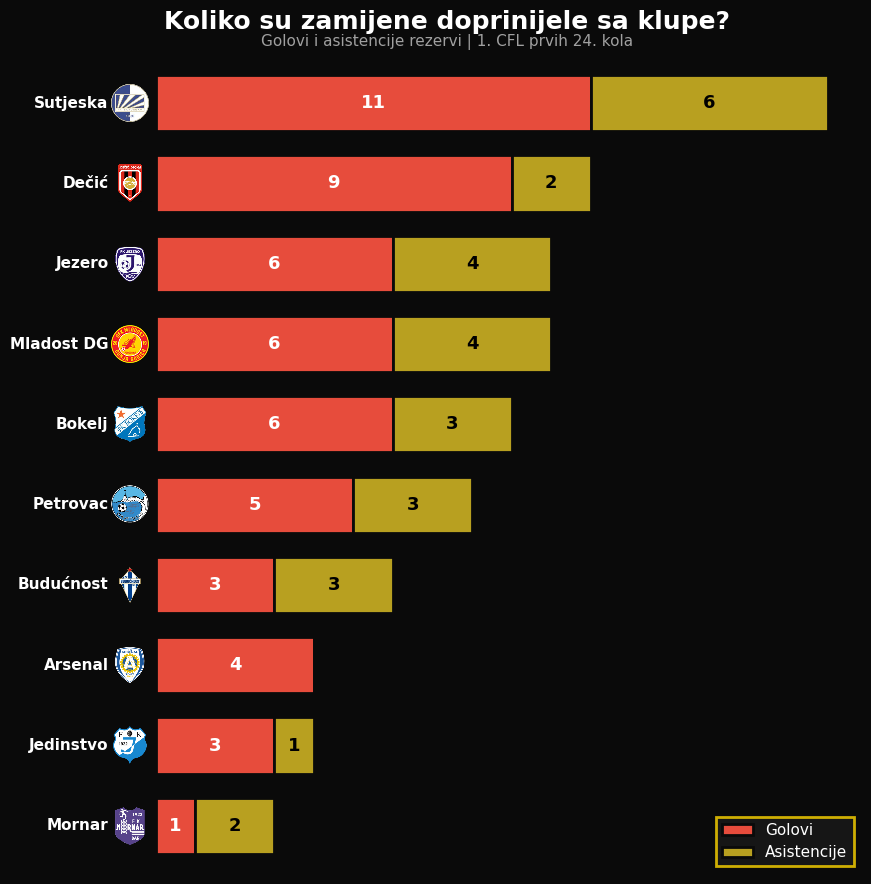

In [15]:

import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ─── Color Constants ──────────────────────────────────────────────
BG_COLOR_DARK      = '#0a0a0a'
GOAL_COLOR_DARK    = '#E74C3C'
ASSIST_COLOR_GOLD  = '#B8A020'
TEXT_COLOR_LIGHT   = '#FFFFFF'

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor(BG_COLOR_DARK)
ax.set_facecolor(BG_COLOR_DARK)

y_positions = np.arange(len(substitute_impact))
BAR_START_X = 0.65
LOGO_X_CENTER = 0
TEXT_X_END = -0.55

ax.barh(
    y_positions,
    substitute_impact['Goals'],
    height=0.7,
    left=BAR_START_X,
    color=GOAL_COLOR_DARK,
    label='Golovi',
    edgecolor=BG_COLOR_DARK,
    linewidth=2,
)
ax.barh(
    y_positions,
    substitute_impact['Assists'],
    height=0.7,
    left=BAR_START_X + substitute_impact['Goals'],
    color=ASSIST_COLOR_GOLD,
    label='Asistencije',
    edgecolor=BG_COLOR_DARK,
    linewidth=2,
)

for y_idx, (_, row) in enumerate(substitute_impact.iterrows()):
    if row['Goals'] > 0:
        ax.text(
            BAR_START_X + row['Goals'] / 2, y_idx,
            f"{int(row['Goals'])}",
            ha='center', va='center', fontsize=13, fontweight='bold', color='white',
        )
    if row['Assists'] > 0:
        ax.text(
            BAR_START_X + row['Goals'] + row['Assists'] / 2, y_idx,
            f"{int(row['Assists'])}",
            ha='center', va='center', fontsize=13, fontweight='bold', color='black',
        )

TEAM_LOGOS_DIR = PROCESSED_DATA_DIR / 'team_logos'
for y_idx, (_, row) in enumerate(substitute_impact.iterrows()):
    logo_path = TEAM_LOGOS_DIR / f"{row['team_id']}.png"
    if not logo_path.exists():
        continue
    try:
        logo_img = mpimg.imread(str(logo_path))
        im = OffsetImage(logo_img, zoom=0.18)
        ab = AnnotationBbox(im, (LOGO_X_CENTER, y_idx),
                            xycoords='data', frameon=False, pad=0, zorder=10)
        ax.add_artist(ab)
    except Exception as exc:
        print(f"Logo load failed for {row['team_id']}: {exc}")

for y_idx, (_, row) in enumerate(substitute_impact.iterrows()):
    label = row['short_name'] if pd.notna(row['short_name']) else row['team_name']
    ax.text(
        TEXT_X_END, y_idx, label,
        ha='right', va='center', fontsize=11, color=TEXT_COLOR_LIGHT, fontweight='600',
    )

ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(-2.0, BAR_START_X + (substitute_impact['Total'].max() * 1.05))
ax.set_ylim(-0.6, len(substitute_impact) - 0.4)

fig.suptitle(
    "Koliko su zamijene doprinijele sa klupe?",
    fontsize=18, fontweight='bold', color=TEXT_COLOR_LIGHT, y=0.98,
)
fig.text(
    0.5, 0.94,
    "Golovi i asistencije rezervi | 1. CFL prvih 24. kola",
    fontsize=11, color='#A0A0A0', ha='center',
)

fig.subplots_adjust(left=0.06, right=0.96, top=0.93, bottom=0.02)

legend = ax.legend(
    loc='lower right', frameon=True, fancybox=False, fontsize=11,
    edgecolor='#FFD700', facecolor='#1a1a1a', labelcolor=TEXT_COLOR_LIGHT,
)
legend.get_frame().set_linewidth(2)

output_path = FIGURES_DIR / 'substitute_impact.png'
plt.savefig(output_path, dpi=300, facecolor=BG_COLOR_DARK, bbox_inches='tight')
print(f"\n✅ Saved to: {output_path}")
plt.show()
